# Exploratory Data Analysis in Python

This notebook shows a practical EDA workflow using public datasets bundled with `scikit-learn`, so no internet connection is required.

We will use:
- `load_breast_cancer` for classification-style EDA
- `load_diabetes` for regression-style EDA

The goal is to inspect data quality, distributions, relationships between variables, class separability, and feature-target patterns.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix, parallel_coordinates
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

## 1. Load a Classification Dataset

The breast cancer dataset contains numeric measurements from cell nuclei. The target is binary: malignant or benign.

In [3]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()
df["diagnosis"] = df["target"].map(dict(enumerate(cancer.target_names)))

features = list(cancer.feature_names)
target_col = "diagnosis"

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df[features].describe().T.head(10))
display(df[target_col].value_counts().to_frame("count"))

Rows: 569
Columns: 32


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


,count
diagnosis,
benign,357
malignant,212


## 2. Target Balance

For classification tasks, checking class balance is one of the first useful EDA steps. Strong imbalance affects evaluation metrics and model training.

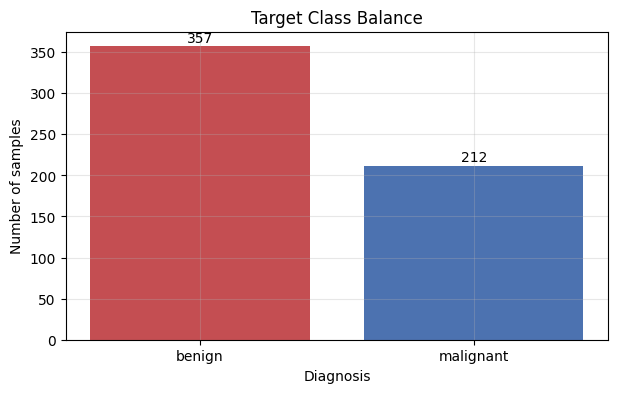

In [5]:
target_counts = df[target_col].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(target_counts.index, target_counts.values, color=["#C44E52", "#4C72B0"])
ax.set_title("Target Class Balance")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of samples")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f"{height}", ha="center")

plt.show()

## 3. Missing Values

This dataset has no missing values, so the first chart will be empty. To demonstrate a useful missingness visualization, the second chart adds a small synthetic missingness pattern to a copy of the data.

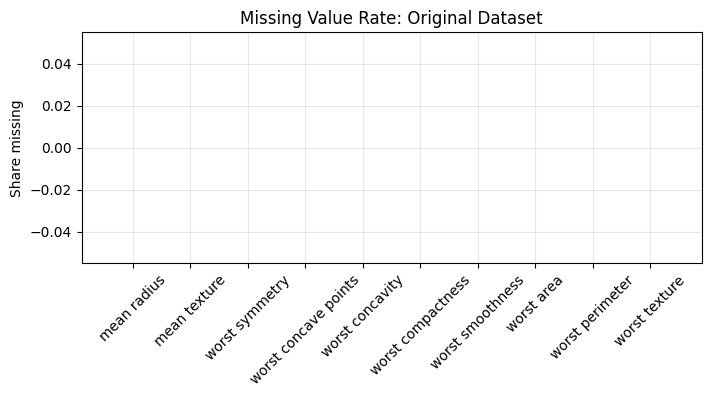

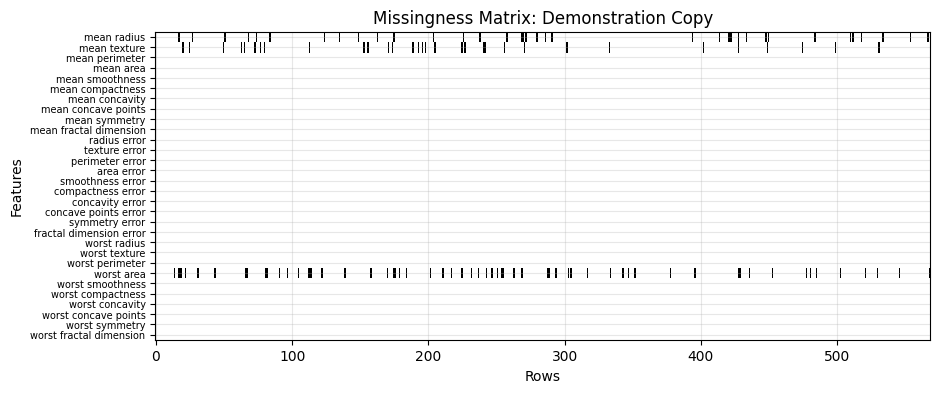

In [6]:
missing_rate = df[features].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(missing_rate.index[:10], missing_rate.values[:10], color="#55A868")
ax.set_title("Missing Value Rate: Original Dataset")
ax.set_ylabel("Share missing")
ax.tick_params(axis="x", rotation=45)
plt.show()

demo_missing = df[features].copy()
rng = np.random.default_rng(RANDOM_STATE)
for col, rate in {"mean radius": 0.08, "mean texture": 0.05, "worst area": 0.12}.items():
    mask = rng.random(len(demo_missing)) < rate
    demo_missing.loc[mask, col] = np.nan

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(demo_missing.isna().T, aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("Missingness Matrix: Demonstration Copy")
ax.set_xlabel("Rows")
ax.set_ylabel("Features")
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=7)
plt.show()

## 4. Feature Distributions

Distribution plots help identify skewness, outliers, scale differences, and variables that may need transformation.

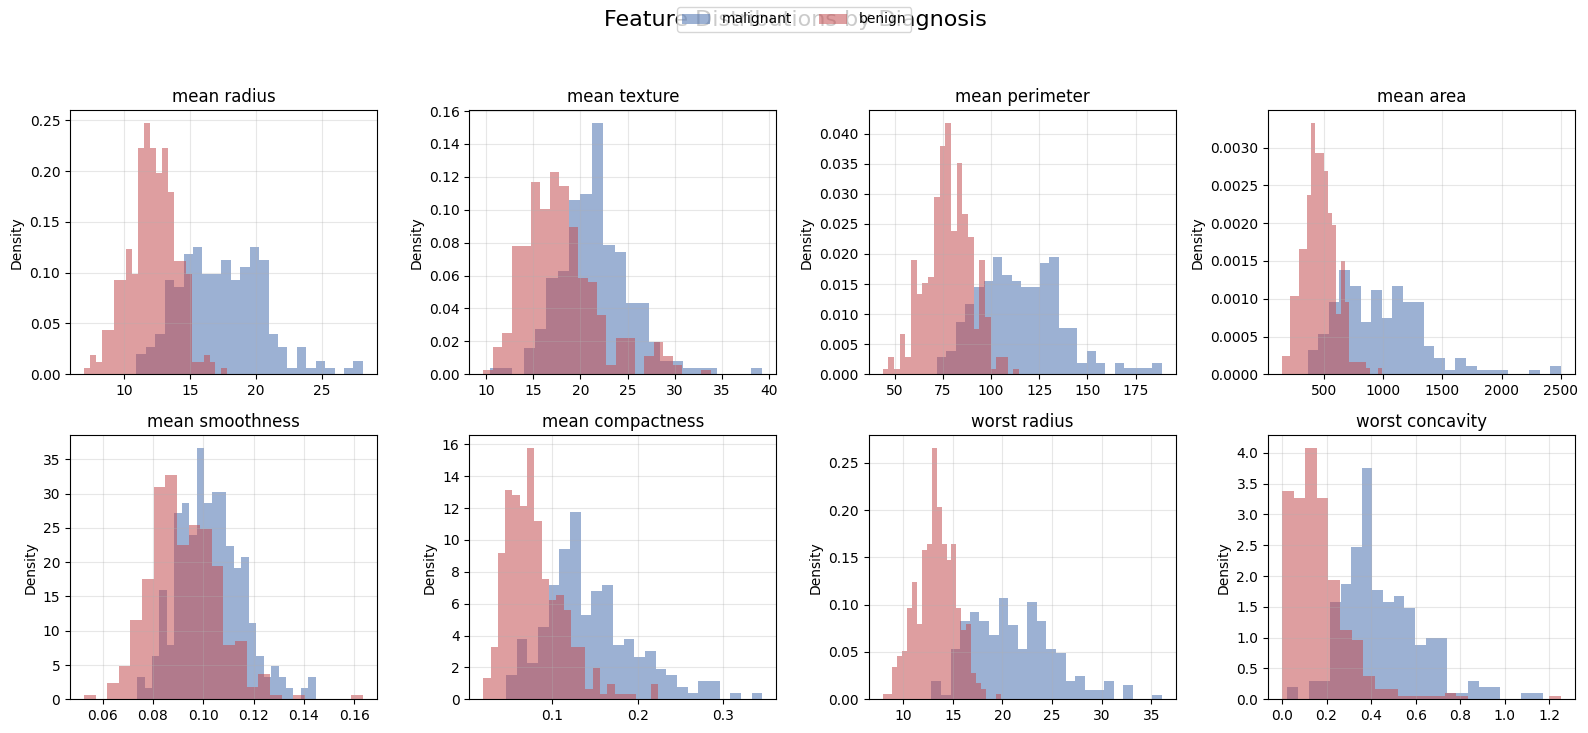

In [7]:
selected_features = [
    "mean radius", "mean texture", "mean perimeter", "mean area",
    "mean smoothness", "mean compactness", "worst radius", "worst concavity"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for ax, col in zip(axes, selected_features):
    for diagnosis, color in zip(cancer.target_names, ["#4C72B0", "#C44E52"]):
        values = df.loc[df[target_col] == diagnosis, col]
        ax.hist(values, bins=24, alpha=0.55, density=True, label=diagnosis, color=color)
    ax.set_title(col)
    ax.set_ylabel("Density")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Feature Distributions by Diagnosis", y=1.04, fontsize=16)
fig.tight_layout()
plt.show()

## 5. Boxplots by Class

Boxplots make class differences and outliers visible. They are especially useful when comparing a numeric feature across categories.

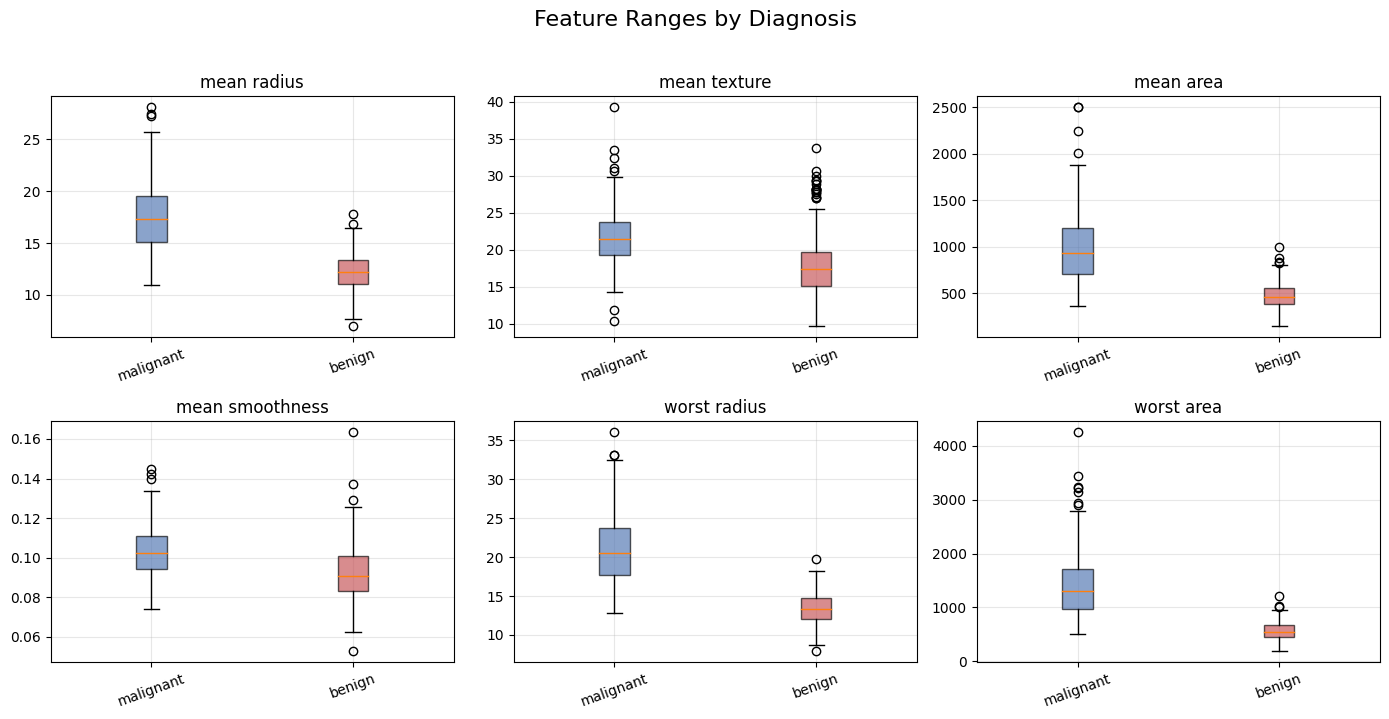

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
box_features = ["mean radius", "mean texture", "mean area", "mean smoothness", "worst radius", "worst area"]

for ax, col in zip(axes, box_features):
    groups = [df.loc[df[target_col] == name, col] for name in cancer.target_names]
    bp = ax.boxplot(groups, labels=cancer.target_names, patch_artist=True, showfliers=True)
    for patch, color in zip(bp["boxes"], ["#4C72B0", "#C44E52"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Feature Ranges by Diagnosis", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

## 6. Correlation Heatmap

Correlation helps detect redundant features and groups of measurements that move together.

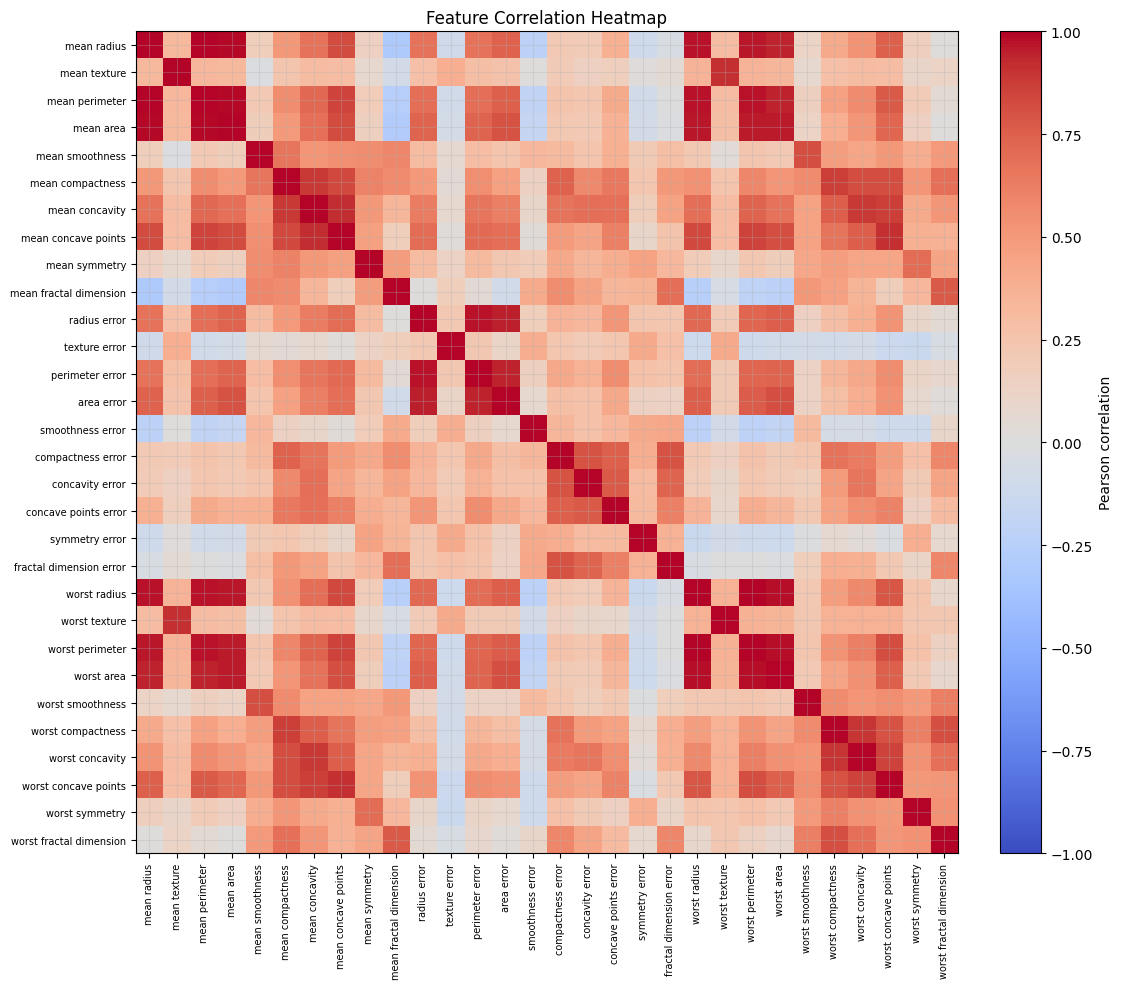

In [9]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Feature Correlation Heatmap")
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90, fontsize=7)
ax.set_yticklabels(features, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")
fig.tight_layout()
plt.show()

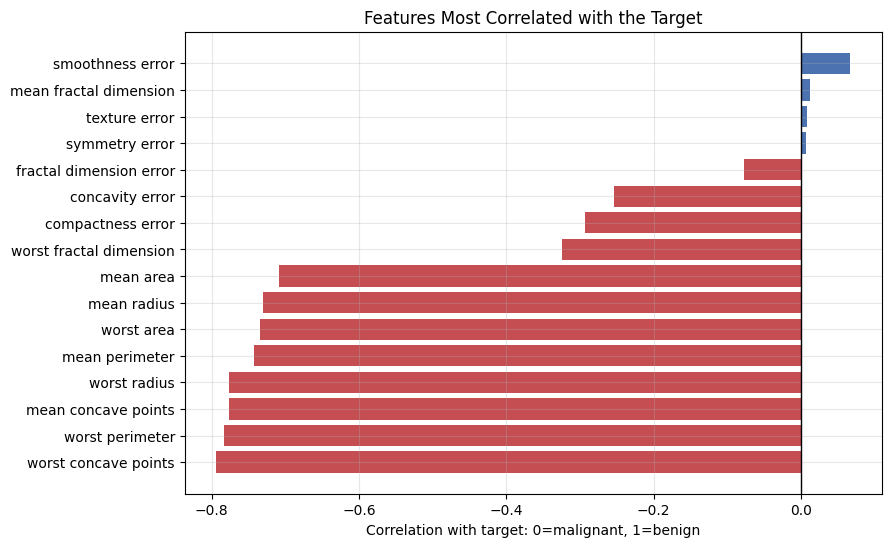

In [10]:
target_corr = df[features + ["target"]].corr()["target"].drop("target").sort_values()
top_target_corr = pd.concat([target_corr.head(8), target_corr.tail(8)])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C44E52" if value < 0 else "#4C72B0" for value in top_target_corr.values]
ax.barh(top_target_corr.index, top_target_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Features Most Correlated with the Target")
ax.set_xlabel("Correlation with target: 0=malignant, 1=benign")
plt.show()

## 7. Scatter Matrix

A scatter matrix gives a compact view of pairwise relationships between a small set of features.

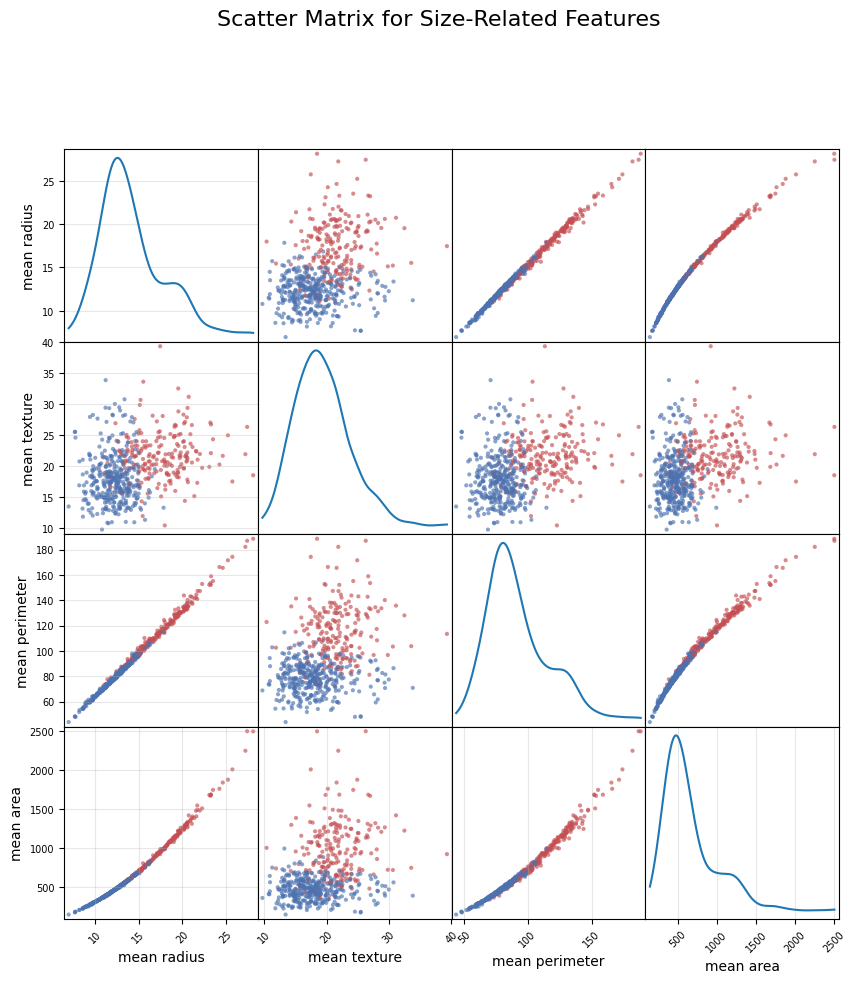

In [11]:
scatter_features = ["mean radius", "mean texture", "mean perimeter", "mean area", target_col]
colors = df[target_col].map({"malignant": "#C44E52", "benign": "#4C72B0"})

axes = scatter_matrix(
    df[scatter_features[:-1]],
    figsize=(10, 10),
    diagonal="kde",
    color=colors,
    alpha=0.65,
    hist_kwds={"bins": 25},
)

for ax in axes.ravel():
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Scatter Matrix for Size-Related Features", y=1.02, fontsize=16)
plt.show()

## 8. PCA Projection

PCA compresses many numeric features into a small number of components. A 2D PCA plot is often useful for checking whether classes are naturally separable.

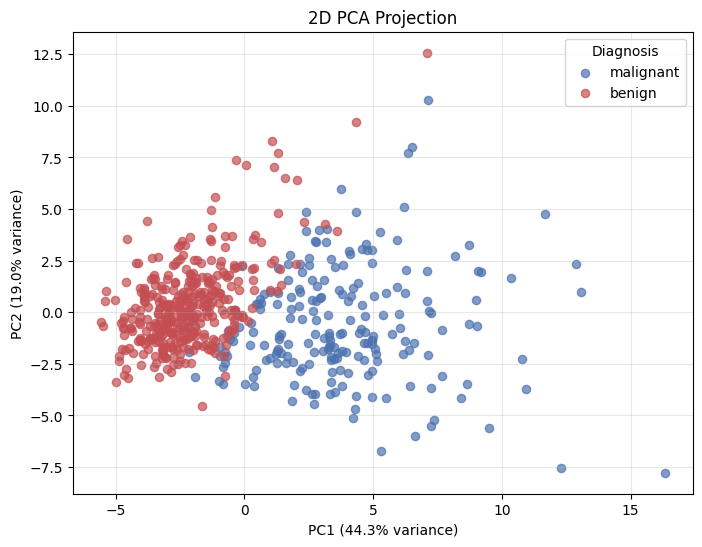

In [12]:
X_scaled = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df[target_col] = df[target_col].values

fig, ax = plt.subplots(figsize=(8, 6))
for diagnosis, color in zip(cancer.target_names, ["#4C72B0", "#C44E52"]):
    subset = pca_df[pca_df[target_col] == diagnosis]
    ax.scatter(subset["PC1"], subset["PC2"], label=diagnosis, alpha=0.7, s=35, color=color)

ax.set_title("2D PCA Projection")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(title="Diagnosis")
plt.show()

## 9. Parallel Coordinates

Parallel coordinates are useful for comparing multivariate patterns across classes. Because variables have different scales, we standardize selected features first.

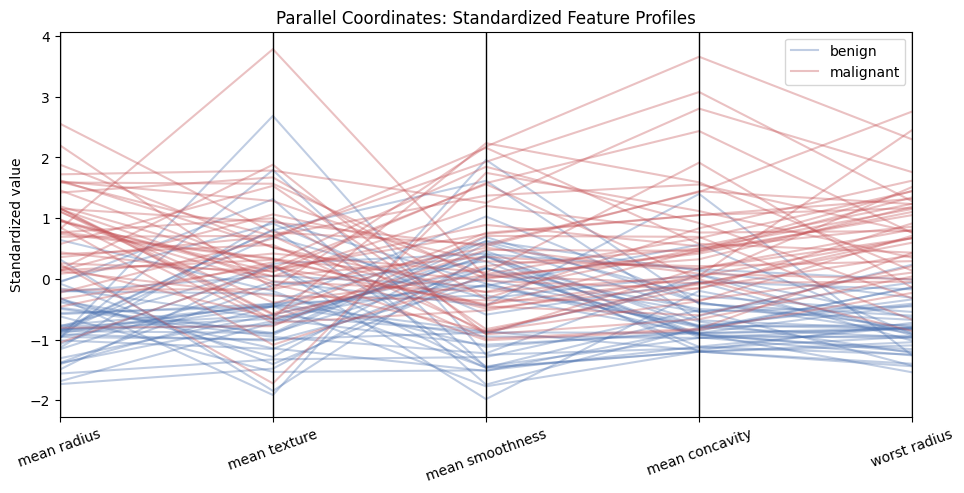

In [13]:
parallel_features = ["mean radius", "mean texture", "mean smoothness", "mean concavity", "worst radius"]
sample = df.groupby(target_col, group_keys=False).sample(n=45, random_state=RANDOM_STATE)

parallel_df = sample[parallel_features + [target_col]].copy()
parallel_df[parallel_features] = StandardScaler().fit_transform(parallel_df[parallel_features])

fig, ax = plt.subplots(figsize=(11, 5))
parallel_coordinates(
    parallel_df,
    class_column=target_col,
    cols=parallel_features,
    color=["#4C72B0", "#C44E52"],
    alpha=0.35,
    ax=ax,
)
ax.set_title("Parallel Coordinates: Standardized Feature Profiles")
ax.set_ylabel("Standardized value")
ax.tick_params(axis="x", rotation=20)
plt.show()

## 10. Regression EDA with the Diabetes Dataset

Regression EDA focuses on the relationship between features and a continuous target.

In [14]:
diabetes = load_diabetes(as_frame=True)
diabetes_df = diabetes.frame.copy()
diabetes_features = list(diabetes.feature_names)

display(diabetes_df.head())
display(diabetes_df.describe().T)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


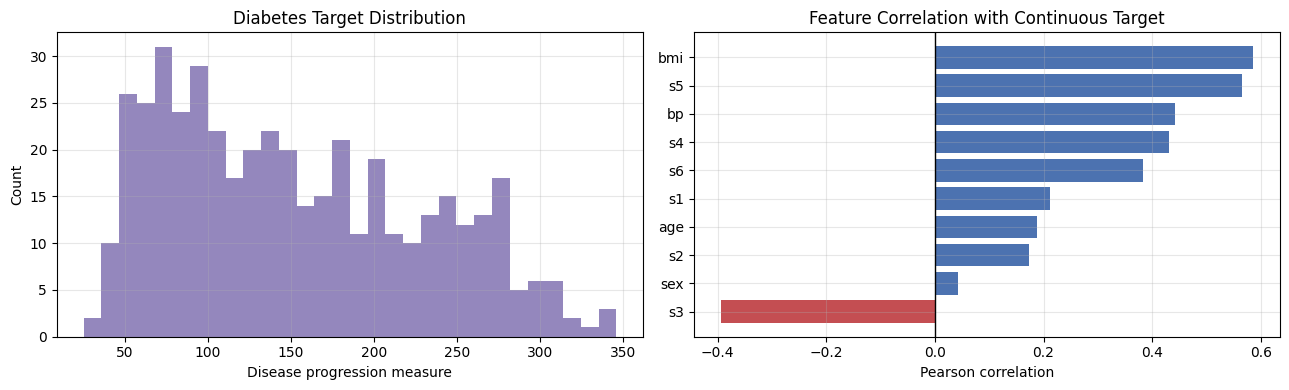

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(diabetes_df["target"], bins=30, color="#8172B2", alpha=0.85)
axes[0].set_title("Diabetes Target Distribution")
axes[0].set_xlabel("Disease progression measure")
axes[0].set_ylabel("Count")

target_corr_reg = diabetes_df.corr()["target"].drop("target").sort_values()
colors = ["#C44E52" if value < 0 else "#4C72B0" for value in target_corr_reg.values]
axes[1].barh(target_corr_reg.index, target_corr_reg.values, color=colors)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Feature Correlation with Continuous Target")
axes[1].set_xlabel("Pearson correlation")

fig.tight_layout()
plt.show()

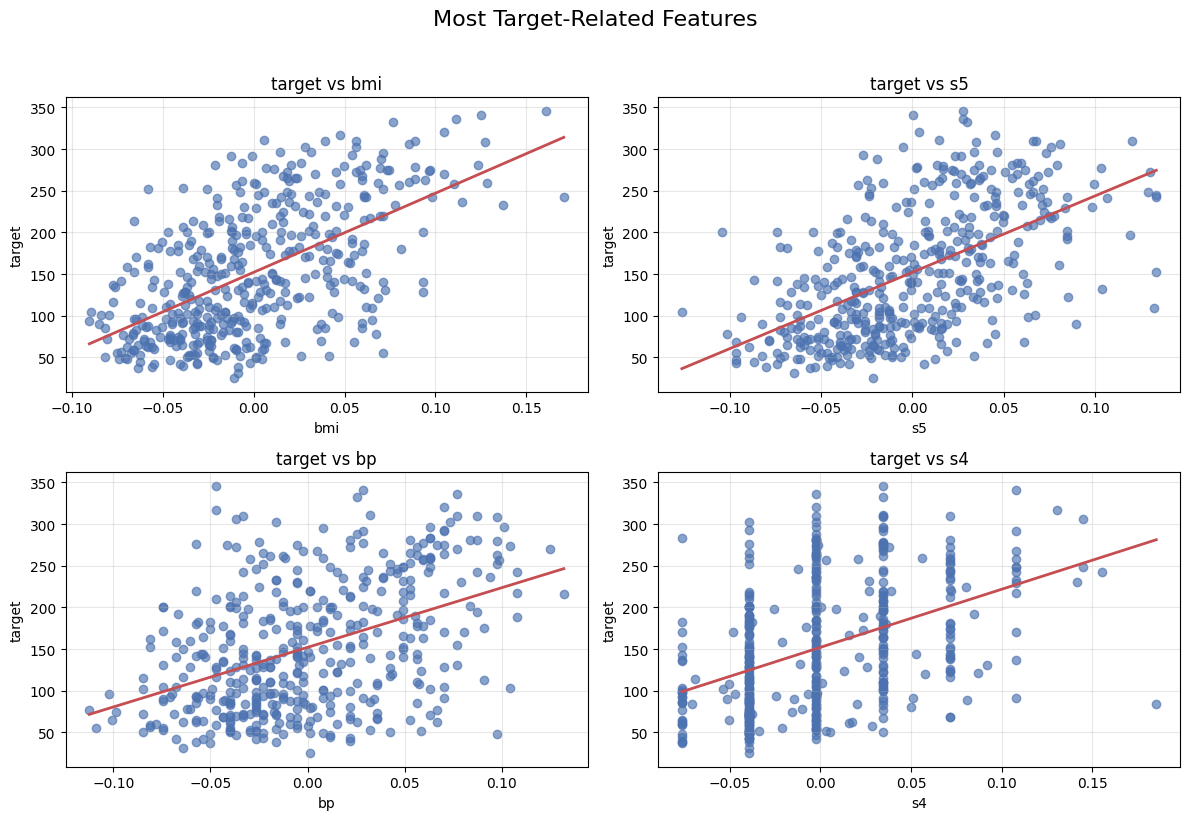

In [16]:
regression_features = target_corr_reg.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, regression_features):
    ax.scatter(diabetes_df[col], diabetes_df["target"], alpha=0.65, color="#4C72B0")
    slope, intercept = np.polyfit(diabetes_df[col], diabetes_df["target"], deg=1)
    x_line = np.linspace(diabetes_df[col].min(), diabetes_df[col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="#C44E52", linewidth=2)
    ax.set_title(f"target vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("target")

fig.suptitle("Most Target-Related Features", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

## EDA Takeaways

A useful EDA notebook usually answers these questions:

1. What is the shape and type of the data?
2. Are there missing values or obvious quality problems?
3. Is the target balanced or skewed?
4. Which features have unusual distributions or outliers?
5. Which features are strongly related to each other?
6. Which features are most related to the target?
7. Do the classes or target patterns look separable before modeling?